## Find interesting results in MPRAlm results
- significant positive negative numbers
- proportion of AF (variant_type) in significant positive and negative numbers
- proportion of cell-type variant (cardiac, neuro, cava or random) in significant positive and negative numbers
- proportion of enformer group in positive and negative numbers (high effect (significant), low effect (not-significant), random: more negative effects than positive effects?)

In [5]:
!pip install pyarrow

In [2]:
import pandas as pd 
import yaml 
import matplotlib.pyplot as plt

config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/config/config.yaml"
config_path = "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/06_variant_analysis/config/config.yaml"
# load config file
with open(config_path, "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

bcMPRAlm_table = pd.read_csv(config["files"]["toptable_standard_control_table"], sep="\t")

print("%s analyzable variants"%(bcMPRAlm_table.shape[0])) # 41284 rows; low config: 42137 rows

# remove lable from variant ID
bcMPRAlm_table["ID"] = bcMPRAlm_table["variant_id"].str.split(":").str[1]


41464 analyzable variants


In [3]:
# investigate the ID column
# check number of pipes in ID column
sum(bcMPRAlm_table.ID.str.count(r'\|') == 3)
# bcMPRAlm_table.shape[0]
# => some have not the same pipe number => check pipe number distribution

41043

In [4]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID
0,1.456812,1.860281,16.887425,2.660743e-54,1.103250e-49,111.530180,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...
1,1.606197,0.969005,12.616945,9.251426e-32,1.918006e-27,60.057828,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...
2,1.531276,0.923153,12.197297,3.871885e-30,5.351462e-26,56.506252,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...
3,0.907774,0.994476,11.422970,2.968129e-28,3.076763e-24,53.219004,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...
4,-1.406837,0.849172,-10.628519,8.330598e-24,6.908398e-20,42.509871,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...
...,...,...,...,...,...,...,...,...
41459,0.001067,0.148021,0.013399,9.893122e-01,9.985585e-01,-6.737826,cardiac_neuro_cava_random:NRXN1|ENSG0000017991...,NRXN1|ENSG00000179915.25|EH38E1997228|2-503360...
41460,-0.000931,0.030328,-0.011657,9.907019e-01,9.986675e-01,-6.737838,cardiac_neuro_cava_random:PHACTR1|ENSG00000112...,PHACTR1|ENSG00000112137.19|EH38E2447179|6-1316...
41461,-0.000932,0.096385,-0.011486,9.908387e-01,9.986675e-01,-6.737840,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542473-T-C
41462,-0.000303,0.242820,-0.003851,9.969282e-01,9.996025e-01,-6.737858,cardiac_neuro_cava_random:DAOA|ENSG00000182346...,DAOA|ENSG00000182346.22|EH38E3079721|13-105499...


### Vulcano plot

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# create new column with negative log10 p-value
bcMPRAlm_table["nlog10"] = -np.log10(bcMPRAlm_table["adj.P.Val"])

In [46]:
def get_label(header):
    return header.split(":")[0]

def map_controls(row):
    if get_label(row['variant_id']) == 'cardiac_neuro_cava_random':
        return '#377eb8'
    else: return '#ff7f00'
    
# add class to plot for colors
def map_color_precise(a):
    log2fc, variant_id, nlog10 = a
    log2fc_threshold = 1
    nlog10pvalue_threshold = 2
    if abs(log2fc) >= log2fc_threshold or nlog10 >= nlog10pvalue_threshold:
        if abs(log2fc) >= log2fc_threshold:
            return "interesting_high_log2fc"
        else:
            return "interesting_low_pvalue"
    elif abs(log2fc) < log2fc_threshold or nlog10 < nlog10pvalue_threshold:
        if abs(log2fc) < log2fc_threshold: 
            return "uninteresting_low_log2fc"
        else: 
            return "uninteresting_high_pvalue" 
    return "possibly_interesting"

def map_color(a):
    log2fc, variant_id, nlog10 = a
    log2fc_threshold = 1
    nlog10pvalue_threshold = 2
    if abs(log2fc) >= log2fc_threshold or nlog10 >= nlog10pvalue_threshold:
        return "interesting"
    elif abs(log2fc) < log2fc_threshold or nlog10 < nlog10pvalue_threshold:
        return "uninteresting" 
    return "possibly_interesting"

In [ ]:
# rename adj.P.Val to adjusted_pval
mpralm.rename(columns={'adj.P.Val':'adjusted_pval'}, inplace=True)

In [95]:
bcMPRAlm_table['mpralm_true'] = np.where((bcMPRAlm_table['logFC'] > 0) & (bcMPRAlm_table['adj.P.Val'] <= 0.05), 'positive', 'neutral')
bcMPRAlm_table['mpralm_true'] = np.where((bcMPRAlm_table['logFC'] < 0) & (bcMPRAlm_table['adj.P.Val'] <= 0.05), 'negative', bcMPRAlm_table['mpralm_true'])

up = bcMPRAlm_table[bcMPRAlm_table['mpralm_true'] == 'positive']
down = bcMPRAlm_table[bcMPRAlm_table['mpralm_true'] == 'negative']

In [103]:
not_neutral = bcMPRAlm_table[bcMPRAlm_table['mpralm_true'] != 'neutral']
not_neutral_control = not_neutral[not_neutral['variant_id'].str.startswith('GC')]

In [104]:
not_neutral_control # only one negative control variant is negative (threshold = 0.05)

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,color,is_control,mpralm_true
38,-0.746661,0.61727,-6.789215,2.815750e-11,2.993647e-08,15.192563,GC_Selvarajan:rs1680636_tile1,rs1680636_tile1,7.523799,interesting_low_pvalue,#ff7f00,negative


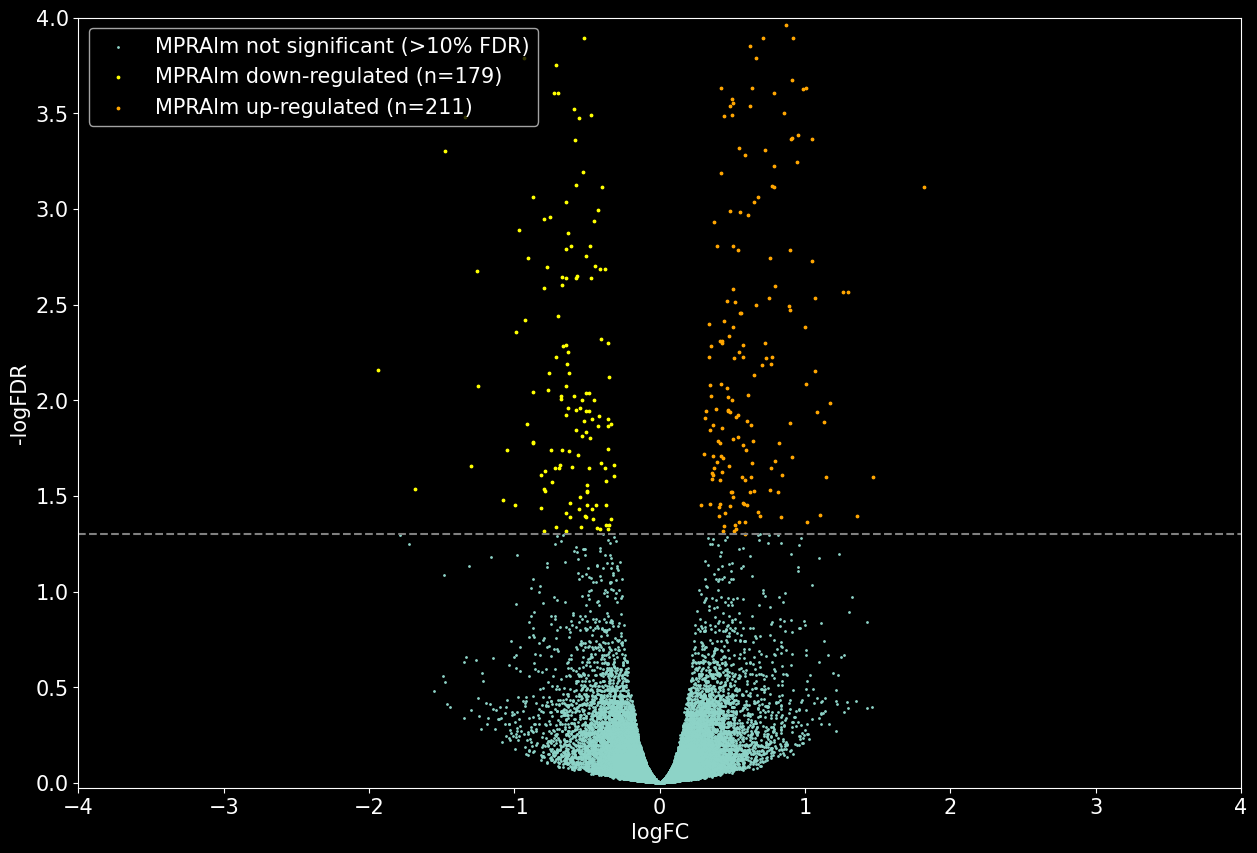

In [97]:
plt.figure(figsize=(15,10))
# make background dark for the plot
plt.style.use('dark_background')
plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label="MPRAlm not significant (>10% FDR)")
plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm down-regulated" + " (n=" + str(down.shape[0]) + ")",color="yellow")
plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm up-regulated"+ " (n=" + str(up.shape[0]) + ")",color="orange")



# Keep x-axis between -4, 4
# keep y-axis between 0, 4
plt.xlim(-4,4)
plt.ylim(-0.025,4)
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
plt.style.use('dark_background')
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

In [88]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,color,is_control
0,1.456812,1.860281,16.887425,2.660743e-54,1.103250e-49,111.530180,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,48.957326,interesting_high_log2fc,#377eb8
1,1.606197,0.969005,12.616945,9.251426e-32,1.918006e-27,60.057828,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.717150,interesting_high_log2fc,#377eb8
2,1.531276,0.923153,12.197297,3.871885e-30,5.351462e-26,56.506252,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.271528,interesting_high_log2fc,#377eb8
3,0.907774,0.994476,11.422970,2.968129e-28,3.076763e-24,53.219004,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,23.511906,interesting_low_pvalue,#377eb8
4,-1.406837,0.849172,-10.628519,8.330598e-24,6.908398e-20,42.509871,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.160623,interesting_high_log2fc,#377eb8
...,...,...,...,...,...,...,...,...,...,...,...
41459,0.001067,0.148021,0.013399,9.893122e-01,9.985585e-01,-6.737826,cardiac_neuro_cava_random:NRXN1|ENSG0000017991...,NRXN1|ENSG00000179915.25|EH38E1997228|2-503360...,0.000627,uninteresting_low_log2fc,#377eb8
41460,-0.000931,0.030328,-0.011657,9.907019e-01,9.986675e-01,-6.737838,cardiac_neuro_cava_random:PHACTR1|ENSG00000112...,PHACTR1|ENSG00000112137.19|EH38E2447179|6-1316...,0.000579,uninteresting_low_log2fc,#377eb8
41461,-0.000932,0.096385,-0.011486,9.908387e-01,9.986675e-01,-6.737840,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542473-T-C,0.000579,uninteresting_low_log2fc,#377eb8
41462,-0.000303,0.242820,-0.003851,9.969282e-01,9.996025e-01,-6.737858,cardiac_neuro_cava_random:DAOA|ENSG00000182346...,DAOA|ENSG00000182346.22|EH38E3079721|13-105499...,0.000173,uninteresting_low_log2fc,#377eb8


In [33]:
bcMPRAlm_table['is_control'] = bcMPRAlm_table.apply(map_controls, axis=1)

In [36]:
bcbcMPRAlm_table_control = bcMPRAlm_table[bcMPRAlm_table["is_control"] == "#ff7f00"]
bcbcMPRAlm_table_control

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,color,is_control
38,-0.746661,0.617270,-6.789215,2.815750e-11,2.993647e-08,15.192563,GC_Selvarajan:rs1680636_tile1,rs1680636_tile1,7.523799,interesting_low_pvalue,#ff7f00
693,0.844633,-0.033200,2.938038,3.589229e-03,1.955635e-01,-1.923092,GC_Selvarajan:rs1965983_tile1,rs1965983_tile1,0.708712,uninteresting_low_log2fc,#ff7f00
839,0.783773,-0.013252,2.769258,5.988302e-03,2.549270e-01,-2.321256,GC_Selvarajan:rs11084922_tile1,rs11084922_tile1,0.593584,uninteresting_low_log2fc,#ff7f00
849,-0.344149,-0.477969,-2.911165,3.738219e-03,1.989866e-01,-2.338997,GC_Selvarajan:rs12444333,rs12444333,0.701176,uninteresting_low_log2fc,#ff7f00
1208,0.422771,-0.190643,2.604528,9.552587e-03,3.151062e-01,-2.892135,GC_Selvarajan:rs2250645,rs2250645,0.501543,uninteresting_low_log2fc,#ff7f00
...,...,...,...,...,...,...,...,...,...,...,...
40548,-0.013047,0.149248,-0.142518,8.867091e-01,9.878068e-01,-6.621531,GC_Selvarajan:rs4846913_tile1,rs4846913_tile1,0.005328,uninteresting_low_log2fc,#ff7f00
41046,0.017453,-0.010929,0.211467,8.325746e-01,9.798133e-01,-6.685977,GC_Selvarajan:rs11674226_tile1,rs11674226_tile1,0.008857,uninteresting_low_log2fc,#ff7f00
41300,0.009792,0.080754,0.126151,8.996421e-01,9.897256e-01,-6.725342,GC_Selvarajan:rs2625259_tile2,rs2625259_tile2,0.004485,uninteresting_low_log2fc,#ff7f00
41335,0.010403,0.119036,0.132052,8.949741e-01,9.889736e-01,-6.728980,GC_Selvarajan:rs2625259_tile3,rs2625259_tile3,0.004815,uninteresting_low_log2fc,#ff7f00


In [7]:
bcMPRAlm_table['color'] = bcMPRAlm_table[['logFC', 'variant_id', 'nlog10']].apply(map_color_precise, axis=1)
bcMPRAlm_table['color'].value_counts()

# more precise split (interesting: abs(log2fc) >= 1 and nlog10 >= 2
# uninteresting_low_log2fc    40930
# interesting_low_pvalue        191
# interesting_high_log2fc       163

# normal split (interesting: abs(log2fc) >= 1 or nlog10 >= 2)
# color
# uninteresting    40930
# interesting        354

# interesting: abs(log2fc) >= 0.5 or nlog10 >= 2
# color
# uninteresting_low_log2fc    39428
# interesting_high_log2fc      1816
# interesting_low_pvalue         40

# => interesing 1856 variants

# 
# http://localhost:8888/tree?token=2c5277b673e1069ca905260d17529bb763643def53e8ed56 228

color
uninteresting_low_log2fc    41111
interesting_low_pvalue        191
interesting_high_log2fc       162
Name: count, dtype: int64

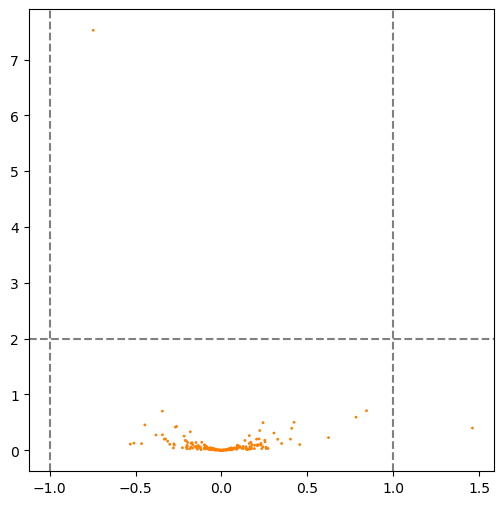

In [38]:
plt.figure(figsize=(6, 6))

plt.scatter(x=bcbcMPRAlm_table_control['logFC'],y=bcbcMPRAlm_table_control['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,color=bcbcMPRAlm_table_control['is_control'])

# plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,color=bcMPRAlm_table['is_control'])
# ax = sns.scatterplot(data=bcMPRAlm_table, x="logFC", y="nlog10", hue="is_control")
# # y-axis label: -log10(adjusted_p-value)
# ax.set(xlabel="log2FC", ylabel="−log10(adjusted p-value)")
# highlight down- or up- regulated genes
# down = bcMPRAlm_table[(bcMPRAlm_table['logFC']<=-2)&(bcMPRAlm_table['adj.P.Val']<=0.01)]
# up = bcMPRAlm_table[(bcMPRAlm_table['logFC']>=2)&(bcMPRAlm_table['adj.P.Val']<=0.01)]



plt.axvline(1,color="grey",linestyle="--")
plt.axvline(-1,color="grey",linestyle="--")
plt.axhline(2,color="grey",linestyle="--")

# ax.axhline(2, zorder = 0, c='k', ls = '--')
# ax.axvline(1, zorder = 0, c='k', ls = '--')
# ax.axvline(-1, zorder = 0, c='k', ls = '--')

In [ ]:
### better control correlation using 

In [47]:
file_path = '/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/05_variant_region_list/controll_header.tsv'
control_header = pd.read_csv(file_path, sep="\t")
control_header['label'] = control_header['header'].apply(get_label)

In [51]:
def get_ratio(header):
    """'C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A::chr4:155359187-155359457-mean_ratio2.42' => 2.42"""
    return float(header.split('mean_ratio')[-1])

In [57]:
log_ratio_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_merged.tsv.gz"
log_ratio = pd.read_csv(log_ratio_path, sep="\t")
log_ratio

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.044034,0.062169,106
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.330882,1.220876,99
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.137747,0.186180,68
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.221316,0.288437,89
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.018761,0.026816,54
...,...,...,...,...,...,...,...,...,...,...
224008,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,968,0.104597,0.206934,2.073894,1.052342,75
224009,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,78,230,0.108453,0.141832,1.370895,0.455118,26
224010,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,69,100,0.086015,0.055287,0.673786,-0.569638,29
224011,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,342,655,0.118881,0.100978,0.890402,-0.167471,104


In [73]:
pos_neuro_cd

,header,label,given_ratio,name,ratio
0,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,2.42,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,0.750000
1,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,2.42,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,1.507842
2,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,2.42,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,1.782164
3,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,2.34,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,3.090278
4,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,2.34,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,2.095457
...,...,...,...,...,...
256,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,1.271118
257,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,1.439994
258,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,1.875000
259,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,0.465657


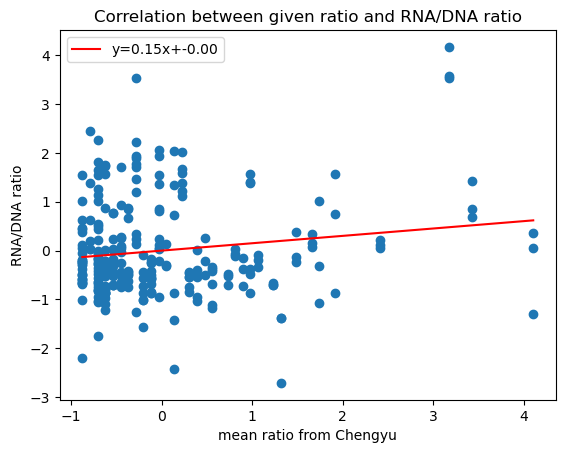

In [84]:
# pos_neuro_cd = control_header[control_header['label'] == 'C_positive_neuron_CD']
# pos_neuro_cd['given_ratio'] = pos_neuro_cd['header'].apply(get_ratio)
# pos_neuro_cd = pos_neuro_cd.merge(log_ratio[['name', 'log2']], left_on="header", right_on="name")
# correlation plot between given ratio and log2 ratio
import matplotlib.pyplot as plt
plt.scatter(pos_neuro_cd['given_ratio'], pos_neuro_cd['log2'])
plt.xlabel("mean ratio from Chengyu")
plt.ylabel("RNA/DNA ratio")
# fit line 
import numpy as np
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(pos_neuro_cd['given_ratio'], pos_neuro_cd['log2'])
line = slope*pos_neuro_cd['given_ratio']+intercept
plt.plot(pos_neuro_cd['given_ratio'], line, 'r', label='y={:.2f}x+{:.2f}'.format(slope,intercept))
plt.legend()
plt.title("Correlation between given ratio and RNA/DNA ratio")
plt.show()



In [ ]:
# median normalize the log2 column
log_ratio['log2'] = log_ratio['log2'] - log_ratio['log2'].median()

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pos_neuro_cd['log2'] = scaler.fit_transform(pos_neuro_cd['log2'])

# StandardScaler().fit_transform(pos_neuro_cd[['given_ratio', '']])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [83]:
pos_neuro_cd

,header,label,given_ratio,name,log2
0,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,4.101950,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,-1.287817
1,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,4.101950,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,0.049655
2,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,4.101950,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,0.369771
3,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,3.427285,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,1.423937
4,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,3.427285,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,0.679918
...,...,...,...,...,...
256,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,-0.277421
257,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,-0.038520
258,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,0.467024
259,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,-2.200627


In [82]:
print(stats.pearsonr(pos_neuro_cd['given_ratio'], pos_neuro_cd['log2']))

PearsonRResult(statistic=0.1510785243371385, pvalue=0.014562828313939583)


In [70]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,color,is_control
0,1.456812,1.860281,16.887425,2.660743e-54,1.103250e-49,111.530180,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,48.957326,interesting_high_log2fc,#377eb8
1,1.606197,0.969005,12.616945,9.251426e-32,1.918006e-27,60.057828,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.717150,interesting_high_log2fc,#377eb8
2,1.531276,0.923153,12.197297,3.871885e-30,5.351462e-26,56.506252,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.271528,interesting_high_log2fc,#377eb8
3,0.907774,0.994476,11.422970,2.968129e-28,3.076763e-24,53.219004,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,23.511906,interesting_low_pvalue,#377eb8
4,-1.406837,0.849172,-10.628519,8.330598e-24,6.908398e-20,42.509871,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.160623,interesting_high_log2fc,#377eb8
...,...,...,...,...,...,...,...,...,...,...,...
41459,0.001067,0.148021,0.013399,9.893122e-01,9.985585e-01,-6.737826,cardiac_neuro_cava_random:NRXN1|ENSG0000017991...,NRXN1|ENSG00000179915.25|EH38E1997228|2-503360...,0.000627,uninteresting_low_log2fc,#377eb8
41460,-0.000931,0.030328,-0.011657,9.907019e-01,9.986675e-01,-6.737838,cardiac_neuro_cava_random:PHACTR1|ENSG00000112...,PHACTR1|ENSG00000112137.19|EH38E2447179|6-1316...,0.000579,uninteresting_low_log2fc,#377eb8
41461,-0.000932,0.096385,-0.011486,9.908387e-01,9.986675e-01,-6.737840,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542473-T-C,0.000579,uninteresting_low_log2fc,#377eb8
41462,-0.000303,0.242820,-0.003851,9.969282e-01,9.996025e-01,-6.737858,cardiac_neuro_cava_random:DAOA|ENSG00000182346...,DAOA|ENSG00000182346.22|EH38E3079721|13-105499...,0.000173,uninteresting_low_log2fc,#377eb8


In [69]:
# investigate significant results
bcMPRAlm_table[bcMPRAlm_table['adj.P.Val'] < 0.05] # 390 
bcMPRAlm_table[bcMPRAlm_table['logFC'] > 1.4].shape # 11

(11, 11)

Looking into the results of the experiment:
- standard vs lowConfig: 
- correlation of DNA and RNA counts per replicate: (problem with plotting in MPRAsnakeflow)
   - DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_DNA_pairwise_minThreshold.png`
   - Ratio: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_Ratio_pairwise_minThreshold.png`
   - RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_RNA_pairwise_minThreshold.png`
- barcode: assigned counts vs all counts: correlation among replicates and count per insert distribution 
   - assigned counts DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_barcode_DNA_pairwise.png`
   - assigned counts RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_barcode_RNA_pairwise.png`
   - count: DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_DNA_perBarcode.png`
   - count: RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_RNA_perBarcode.png`
   - all counts DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_barcode_DNA_pairwise.png`
   - all counts RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_barcode_RNA_pairwise.png`
   - count distri DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_RNA_perBarcode.png`
   - count distri RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_DNA_perBarcode.png`


- correlation_lowconfig: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/lowConfig_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_lowConfig_barcode_RNA_pairwise.png`
   - Check up with Martin (check the exact numbers (how many are significant, how many are over log2FC))

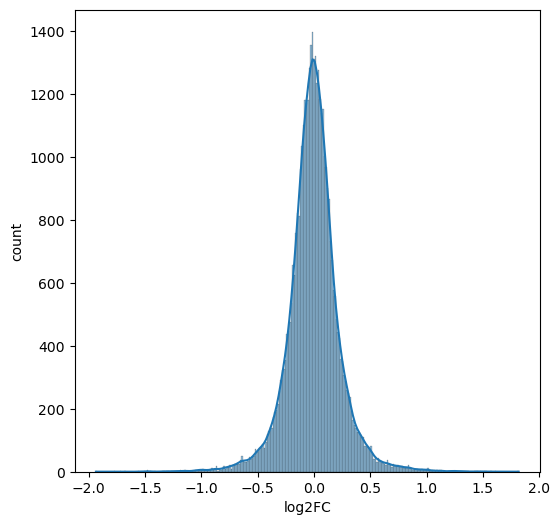

In [12]:
## log2fc distribution of our variants
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=bcMPRAlm_table, x="logFC", kde=True)
ax.set(xlabel="log2FC", ylabel="count")
plt.show()

### Investigate outliers (high log2FC) and not significant
- expectation: only a few barcodes

In [14]:
# filter for high log2fc and not significant
non_sig_high_log2fc = bcMPRAlm_table[(abs(bcMPRAlm_table["logFC"]) >= 1) & (bcMPRAlm_table["adj.P.Val"] > 0.05)] # 1: 101; 0.5: 1524
len(non_sig_high_log2fc)

101

In [13]:
# number of significant variants
sig_variants = bcMPRAlm_table[bcMPRAlm_table["adj.P.Val"] < 0.05]
print(len(sig_variants)) # 398

low_log2fc = bcMPRAlm_table[abs(bcMPRAlm_table["logFC"]) < 0.5]
print(len(low_log2fc)) # 39468

398
39468


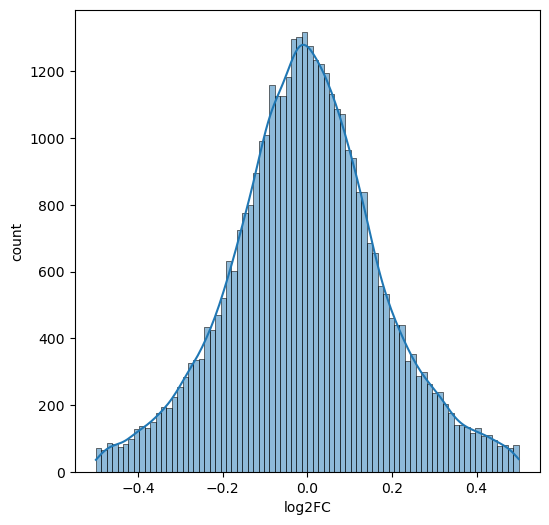

In [24]:
## log2fc distribution
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=low_log2fc, x="logFC", kde=True)
ax.set(xlabel="log2FC", ylabel="count")
plt.show()

### Connect MPRA results 
- Allel Frequency (AF), Allele Count (AC)
- enformer class (high_effect, low_effect, random) 
- Gene_set (neuro, cardiac, cava, random)

In [56]:
# TODO: add connection between bc_MPRAlm_table and enformer tables
# bcMPRAlm_table
# match one enformer to the bcMPRAlm_table
# define a function for it
# does it for all enformer tables
enformer_cardiac_singleton = pd.read_csv(config["files"]["enformer_cardiac_single"], sep="\t")

In [15]:
bcMPRAlm_table.variant_id.tolist()[:10]

['cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G',
 'cardiac_neuro_cava_random:ANKZF1|ENSG00000163516.14|EH38E2076021|2-219267001-T-C',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T',
 'cardiac_neuro_cava_random:ATR|ENSG00000175054.16|EH38E3544406|3-142578095-C-G',
 'cardiac_neuro_cava_random:CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115774-T-C',
 'cardiac_neuro_cava_random:CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G',
 'cardiac_neuro_cava_random:SLC1A2|ENSG00000110436.13|EH38E1532674|11-35289966-C-T',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408083-G-T',
 'cardiac_neuro_cava_random:H1-3|ENSG00000124575.7|EH38E3697725|6-26269112-G-T',
 'cardiac_neuro_cava_random:DISC1|ENSG00000162946.23|EH38E2873486|1-231734633-A-G']

In [57]:
enformer_cardiac_singleton.head()

,#CHROM,POS,ID,REF,ALT,DNase_max,INDEX_max,QUAL,FILTER,INFO,gene_set,variant_type,enformer_class
0,chr6,43797164,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,4254.3410,392_DNASE:CD14-positive,1,PASS,AF=6.57168e-06;AC=1,cardiac,singleton,enformer_high
1,chr18,3059465,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,4022.5996,"177_DNASE:CD8-positive,",1,PASS,AF=6.56866e-06;AC=1,cardiac,singleton,enformer_high
2,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,3591.8310,392_DNASE:CD14-positive,1,PASS,AF=6.57618e-06;AC=1,cardiac,singleton,enformer_high
3,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,2754.7705,401_DNASE:common myeloid,1,PASS,AF=6.56763e-06;AC=1,cardiac,singleton,enformer_high
4,chr7,151848098,PRKAG2|ENSG00000106617.15|EH38E2601935|7-15184...,A,C,2746.3271,392_DNASE:CD14-positive,1,PASS,AF=6.56978e-06;AC=1,cardiac,singleton,enformer_high


### Positive and Negative numbers
- Overall: 
    - standard: 41284
    - lowConfig: 42137
- Number of significant results
    - standard: 398 
    - lowConfig: 53 
    - TODO: Why do I only find 53 with p-value < 0.05?
- Plot of log2FC distribution
- Plot p-value distribution
- Table of positive and negative log2FC
- Plot of p-value distribution (adjusted p value)

In [3]:
def plot_distribution(df, value_column, n_bins=100, output_path="", title="", x_lable=None, y_lable=None):
    """Plot the distribution of the given column and store the plot in given directory"""
    plt.hist(df[value_column], bins=n_bins)
    if title != "":
        plt.title(title)
    if x_lable:
        plt.xlabel(xlabel=x_lable)
    if y_lable:
        plt.ylabel(ylabel=y_lable)
    if output_path != "":
        plt.savefig(config["plots"]["log2_p_sig_hist"])
    plt.show()
    plt.clf()

398 significant variants


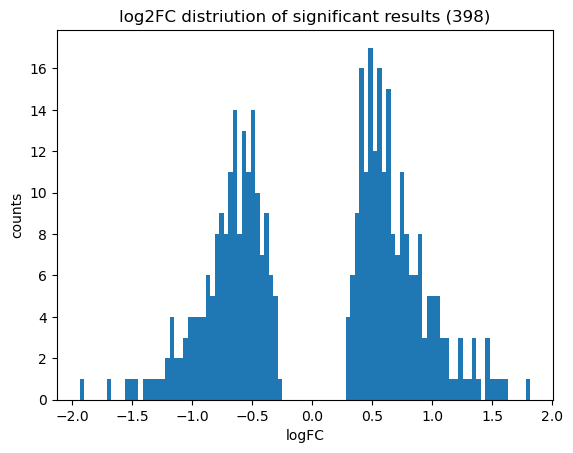

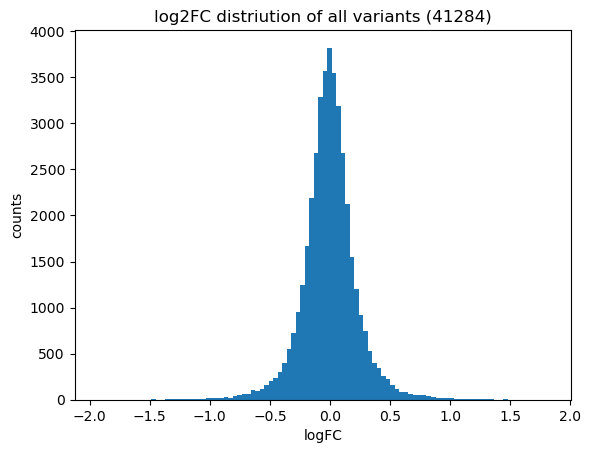

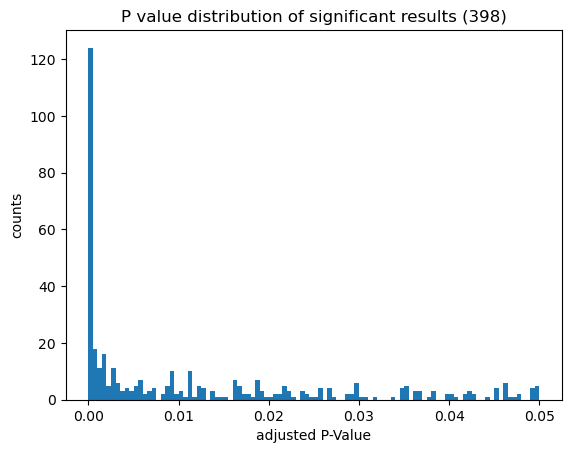

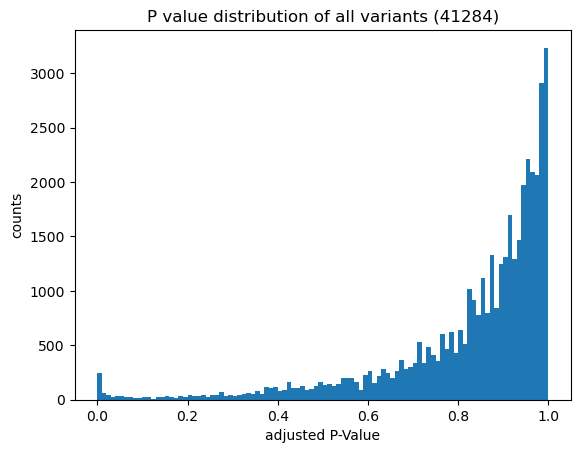

<Figure size 640x480 with 0 Axes>

In [4]:
sig_niveau = 0.05
significant_variants = bcMPRAlm_table[bcMPRAlm_table["adj.P.Val"] < sig_niveau]
print("%s significant variants"%(significant_variants.shape[0]))

# plot log2FC distribution
title = "log2FC distriution of significant results (%s)"%(significant_variants.shape[0])
plot_distribution(df=significant_variants, value_column="logFC", n_bins=100, output_path=config["plots"]["log2_p_sig_hist"], title=title, x_lable="logFC", y_lable="counts")
title = "log2FC distriution of all variants (%s)"%(bcMPRAlm_table.shape[0])
plot_distribution(df=bcMPRAlm_table, value_column="logFC", n_bins=100, output_path=config["plots"]["log2_all_hist"], title=title, x_lable="logFC", y_lable="counts")

# P value distribution
title = "P value distribution of significant results (%s)"%(significant_variants.shape[0])
plot_distribution(df=significant_variants, value_column="adj.P.Val", n_bins=100, output_path=config["plots"]["sig_adj_p_hist"], title=title, x_lable="adjusted P-Value", y_lable="counts")
title = "P value distribution of all variants (%s)"%(bcMPRAlm_table.shape[0])
plot_distribution(df=bcMPRAlm_table, value_column="adj.P.Val", n_bins=100, output_path=config["plots"]["all_adj_p_hist"], title=title, x_lable="adjusted P-Value", y_lable="counts")



### Positive and negative effects
- In all variants
  - Found 20113 (0.487) positive results
  - Found 21171 (0.513) negative results
- Significant (reverse pattern => more positive than negative)
  - Found 214 (0.538) positive results
  - Found 184 (0.462) negative results

In [50]:
# number of positive negative numbers
def split_into_common_rare(df_with_AF_column,  common_threshold=0.05, column="AF"):
    """Splits df into rare and common at threshold"""
    common_vars = df_with_AF_column[df_with_AF_column[column] >= common_threshold]
    rare_vars = df_with_AF_column[df_with_AF_column[column] < common_threshold]
    print(f"Found {len(common_vars)} ({len(common_vars)/len(df_with_AF_column)}) common variants and {len(rare_vars)} ({len(rare_vars)/len(df_with_AF_column)}) rare variants with the common threshold {common_threshold}")
    ultra_rare = df_with_AF_column[df_with_AF_column[column] < 0.01]
    ultra_rare = ultra_rare[ultra_rare["AC"] != 1]
    print(f"Found {len(ultra_rare)} ultra-rare variants")
    print(f"Found {len(df_with_AF_column[df_with_AF_column['AC'] == 1])} singleton variants")
    return common_vars, rare_vars

def split_df_in_pos_neg(df_with_logFC_column, column="logFC", rounding_precision=3):
    """Splits a given data frame based on the logFC into positive and negative values"""
    positive_set = df_with_logFC_column[df_with_logFC_column[column] > 0]
    negative_set = df_with_logFC_column[df_with_logFC_column[column] < 0]
    print(f"Found {len(positive_set)} ({round(len(positive_set)/len(df_with_logFC_column),rounding_precision)}) positive results\nFound {len(negative_set)} ({round(len(negative_set)/len(df_with_logFC_column), rounding_precision)}) negative results")
    return positive_set, negative_set

In [51]:
print("In all variants")
bcMPRAlm_table_positive, bcMPRAlm_table_negative = split_df_in_pos_neg(bcMPRAlm_table)
print("Significant")
sig_positive, sig_negative = split_df_in_pos_neg(significant_variants)

In all variants
Found 20113 (0.487) positive results
Found 21171 (0.513) negative results
Significant
Found 214 (0.538) positive results
Found 184 (0.462) negative results


### Allele frequency (common: AF>1%, rare: AF=<1%, singleton: AC=0)

In [ ]:
# common rare 